<a href="https://colab.research.google.com/github/Alexandre77777/computer_math/blob/main/10.%20%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F%20%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2%20%D0%B8%20%D0%BF%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8F%20%D0%A4%D1%83%D1%80%D1%8C%D0%B5/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9610_%D0%93%D0%B5%D0%BD%D0%B5%D1%80%D0%B0%D1%86%D0%B8%D1%8F_%D1%81%D0%B8%D0%B3%D0%BD%D0%B0%D0%BB%D0%BE%D0%B2_%D0%B8_%D0%BF%D1%80%D0%B5%D0%BE%D0%B1%D1%80%D0%B0%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D1%8F_%D0%A4%D1%83%D1%80%D1%8C%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №10. Генерация сигналов и преобразования Фурье**

# Блок №1. Базовый уровень

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.signal import spectrogram

## **Задание 1: Генерация сигналов**



В этом задании вам нужно создать различные виды сигналов. Сигналы являются основой цифровой обработки сигналов, и умение их генерировать является важным навыком.













1. **Синусоидальный сигнал**: Синусоидальный сигнал можно представить как $A \sin(2\pi ft + \phi)$, где $A$ - амплитуда, $f$ - частота, $\phi$ - фаза.

- Создайте функцию, которая принимает эти параметры, а также длительность сигнала, и возвращает сгенерированный сигнал.

### Пример:



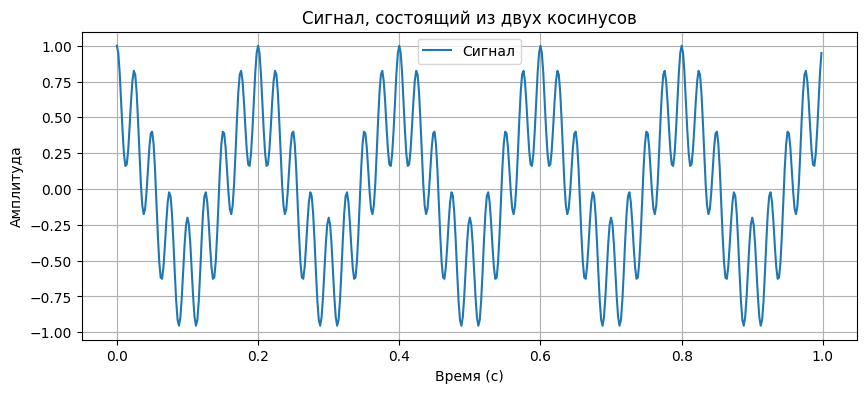

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Параметры времени
T = 1.0         # длительность сигнала в секундах
fs = 500.0      # частота дискретизации (в герцах)
t = np.arange(0, T, 1/fs) # массив времени

# Создание сигнала
f1 = 5.0        # частота первого косинуса
f2 = 40.0       # частота второго косинуса
a1 = 0.6        # амплитуда первого косинуса
a2 = 0.4        # амплитуда второго косинуса
signal = a1*np.cos(2*np.pi*f1*t) + a2*np.cos(2*np.pi*f2*t)

# Визуализация сигнала
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label='Сигнал')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Cигнал, состоящий из двух косинусов')
plt.legend()
plt.grid(True)
plt.show()


### Ваш код:

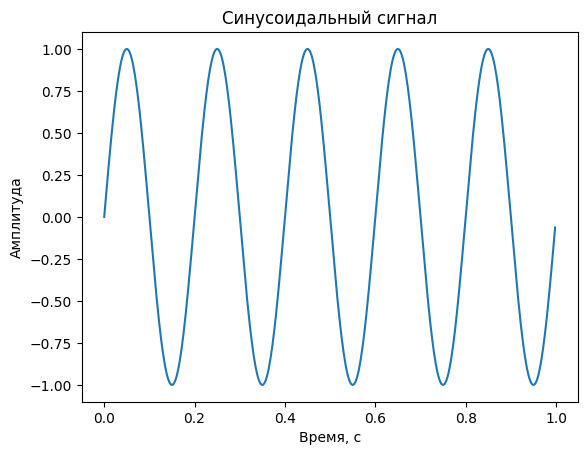

In [3]:
def sine_signal(amplitude, frequency, phase, duration, sample_rate=500):
    time_values = np.arange(0, duration, 1 / sample_rate)
    values = amplitude * np.sin(2 * np.pi * frequency * time_values + phase)
    return time_values, values

t_sine, sine_values = sine_signal(1, 5, 0, 1)
plt.plot(t_sine, sine_values)
plt.title("Синусоидальный сигнал")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.show()

In [4]:
# Пример

2. **Сумма синусоид**: Сигнал, состоящий из суммы двух синусоид, можно представить как $A_1 \sin(2\pi f_1t + \phi_1) + A_2 \sin(2\pi f_2t + \phi_2)$.

- Создайте функцию, которая принимает параметры для двух синусоид, а также длительность сигнала, и возвращает сгенерированный сигнал.

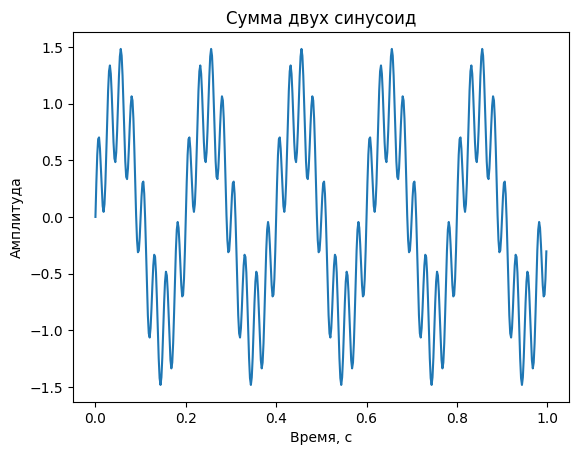

In [5]:
def two_sines(a1, f1, p1, a2, f2, p2, duration, sample_rate=500):
    time_values = np.arange(0, duration, 1 / sample_rate)
    first = a1 * np.sin(2 * np.pi * f1 * time_values + p1)
    second = a2 * np.sin(2 * np.pi * f2 * time_values + p2)
    return time_values, first + second

t_sum, sum_values = two_sines(1, 5, 0, 0.5, 40, 0, 1)
plt.plot(t_sum, sum_values)
plt.title("Сумма двух синусоид")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.show()

In [6]:
# Пример

3. **Шумовой сигнал**: Шумовой сигнал (или белый шум) можно сгенерировать как случайные значения из нормального распределения.

- Создайте функцию, которая принимает амплитуду шума и длительность сигнала, и возвращает сгенерированный шумовой сигнал.

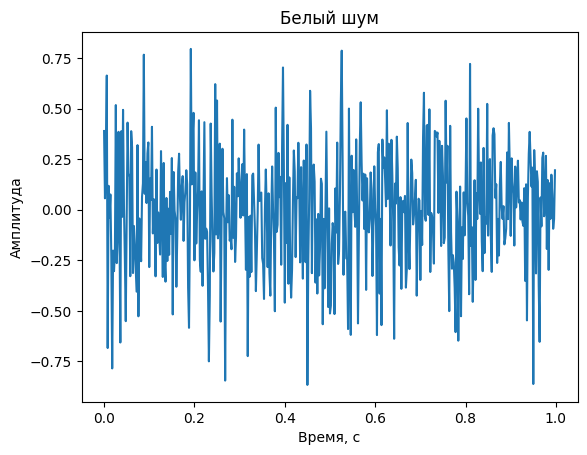

In [7]:
def noise_signal(amplitude, duration, sample_rate=500):
    time_values = np.arange(0, duration, 1 / sample_rate)
    values = amplitude * np.random.normal(size=len(time_values))
    return time_values, values

t_noise, noise_values = noise_signal(0.3, 1)
plt.plot(t_noise, noise_values)
plt.title("Белый шум")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.show()

In [8]:
# Пример

4. **Синусоида плюс шум**: Сигнал, который представляет собой сумму синусоиды и шума, можно сгенерировать путем сложения синусоидального и шумового сигналов.
- Создайте функцию, которая принимает параметры для синусоиды и шума, а также длительность сигнала, и возвращает сгенерированный сигнал.

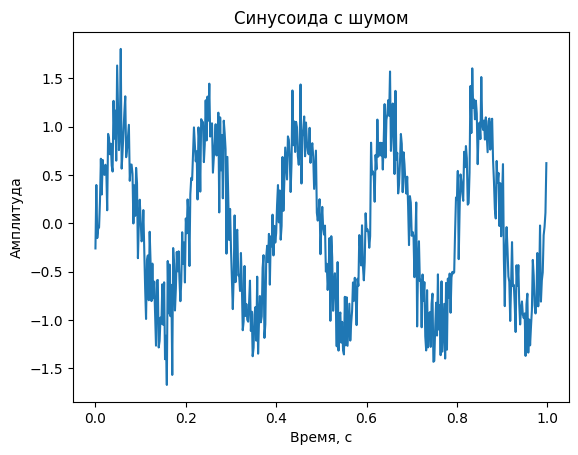

In [9]:
def sine_with_noise(amplitude, frequency, phase, noise_amplitude, duration, sample_rate=500):
    time_values, sine = sine_signal(amplitude, frequency, phase, duration, sample_rate)
    _, noise = noise_signal(noise_amplitude, duration, sample_rate)
    return time_values, sine + noise

t_mixed, mixed_values = sine_with_noise(1, 5, 0, 0.3, 1)
plt.plot(t_mixed, mixed_values)
plt.title("Синусоида с шумом")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.show()

In [10]:
# Пример

## **Задание 2: Преобразование Фурье**


Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Это основной инструмент для анализа сигналов. Создайте функцию, которая принимает сигнал и возвращает его преобразование Фурье.


1. Примените преобразование Фурье к синусоидальному сигналу и визуализируйте результат.


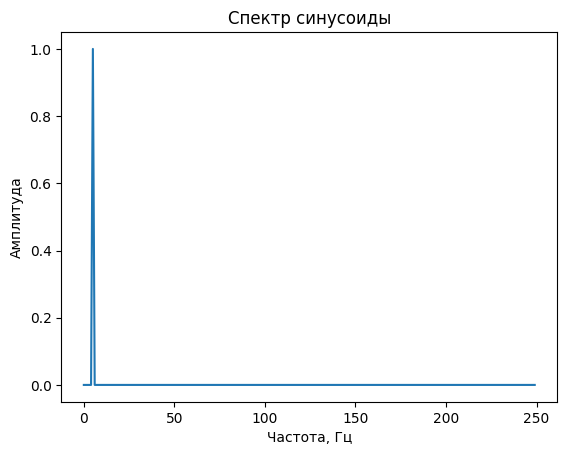

In [11]:
def fourier_transform(values, sample_rate):
    spectrum = fft(values)
    frequencies = fftfreq(len(values), 1 / sample_rate)
    half = len(values) // 2
    return frequencies[:half], 2 * np.abs(spectrum[:half]) / len(values)

frequencies, amplitudes = fourier_transform(sine_values, 500)
plt.plot(frequencies, amplitudes)
plt.title("Спектр синусоиды")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.show()

In [12]:
# Пример

2. Примените преобразование Фурье к сигналу, состоящему из суммы двух синусоид, и визуализируйте результат.


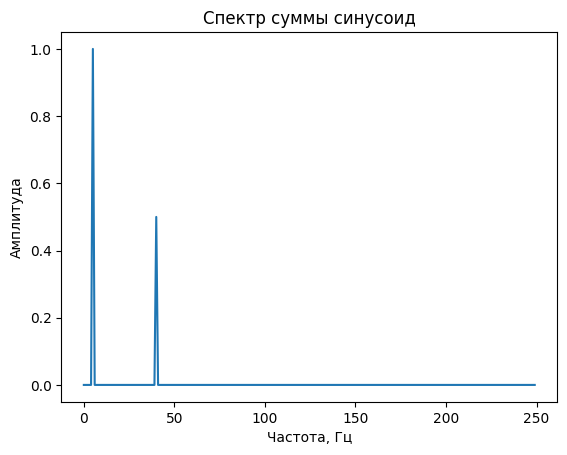

In [13]:
frequencies, amplitudes = fourier_transform(sum_values, 500)
plt.plot(frequencies, amplitudes)
plt.title("Спектр суммы синусоид")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.show()

In [14]:
# Пример

3. Примените преобразование Фурье к шумовому сигналу и визуализируйте результат.


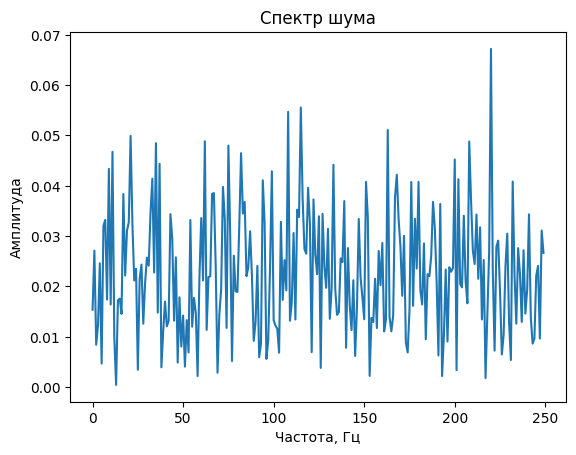

In [15]:
frequencies, amplitudes = fourier_transform(noise_values, 500)
plt.plot(frequencies, amplitudes)
plt.title("Спектр шума")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.show()

In [16]:
# Пример

4. Примените преобразование Фурье к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результат.

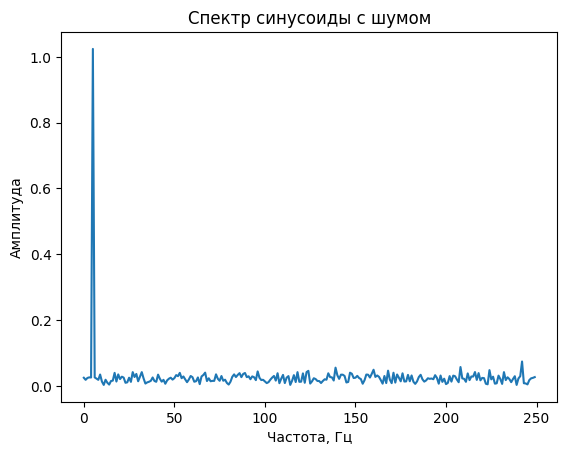

In [17]:
frequencies, amplitudes = fourier_transform(mixed_values, 500)
plt.plot(frequencies, amplitudes)
plt.title("Спектр синусоиды с шумом")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.show()

In [18]:
# Пример

## **Задание 3: Фильтрация сигналов**

Фильтрация сигналов позволяет улучшить качество сигнала, убрав нежелательные частоты. Создайте функцию, которая принимает сигнал и частоту среза, и возвращает отфильтрованный сигнал.




1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.

In [19]:
def low_pass_filter(values, sample_rate, cutoff):
    spectrum = fft(values)
    frequencies = fftfreq(len(values), 1 / sample_rate)
    spectrum[np.abs(frequencies) > cutoff] = 0
    return ifft(spectrum).real

In [20]:
# Пример

2. Примените эту функцию к сигналу, который представляет собой сумму синусоиды и шума, и визуализируйте результаты до и после фильтрации.

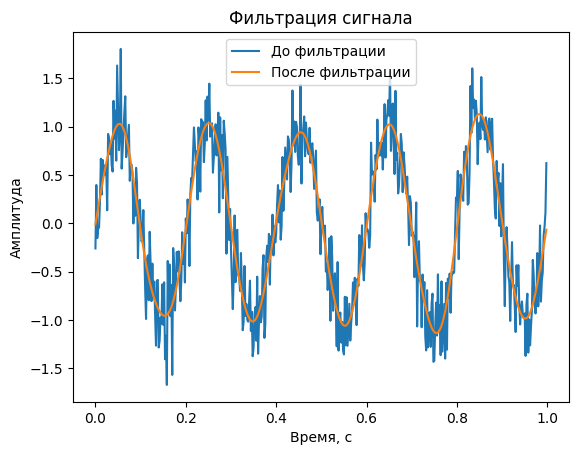

In [21]:
filtered_values = low_pass_filter(mixed_values, 500, 15)
plt.plot(t_mixed, mixed_values, label="До фильтрации")
plt.plot(t_mixed, filtered_values, label="После фильтрации")
plt.title("Фильтрация сигнала")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.legend()
plt.show()

In [22]:
# Пример

## **Задание 4: Анализ сигналов**

Анализ сигналов включает в себя различные методы и техники для изучения и понимания сигналов. Создайте функцию, которая принимает сигнал и возвращает его спектрограмму (**scipy.signal.spectrogram**).


**Спектрограмма** - это визуальное представление спектра частот сигнала во времени. Она показывает, какие частоты присутствуют в сигнале в каждый момент времени. Вот как правильно понимать спектрограмму:

- **Ось X**: Это время. Она показывает продолжительность сигнала. Каждый столбец на спектрограмме представляет собой отдельный момент времени.

- **Ось Y**: Это частота. Она показывает различные частоты, которые присутствуют в сигнале. Каждая строка на спектрограмме представляет собой отдельную частоту.

- **Значение**: Значение в каждой точке (x, y) показывает амплитуду (или интенсивность) данной частоты в данное время. Обычно более яркие цвета означают большую амплитуду, а более темные цвета - меньшую амплитуду.

Таким образом, спектрограмма позволяет вам видеть, как меняется спектральный состав сигнала во времени. Это может быть полезно во многих областях, включая анализ речи, музыку, радиосигналы и многое другое. Например, в анализе речи вы можете видеть, как меняются форманты (основные частоты) во время произношения различных звуков. В музыке вы можете видеть, как меняются ноты во время проигрывания песни.

1. Создайте функцию для вычисления и визуализации спектрограммы сигнала.


In [23]:
def show_spectrogram(values, sample_rate, title):
    frequencies, times, power = spectrogram(values, fs=sample_rate)
    plt.pcolormesh(times, frequencies, power, shading="auto")
    plt.title(title)
    plt.xlabel("Время, с")
    plt.ylabel("Частота, Гц")
    plt.colorbar(label="Мощность")
    plt.show()

2. Примените эту функцию к различным сигналам, которые вы сгенерировали и проанализировали в предыдущих заданиях.

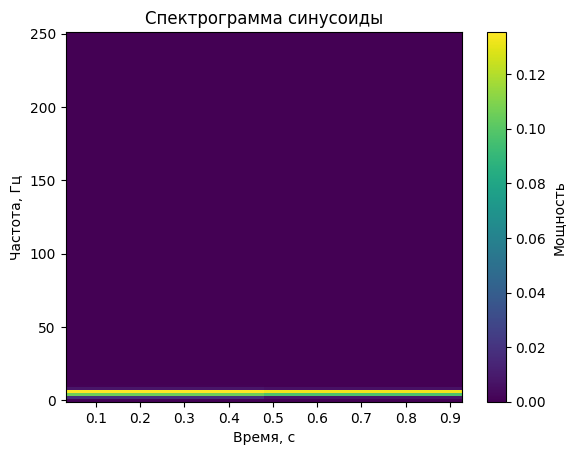

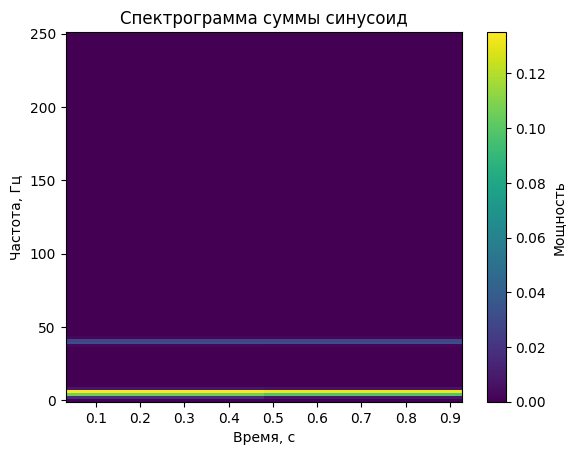

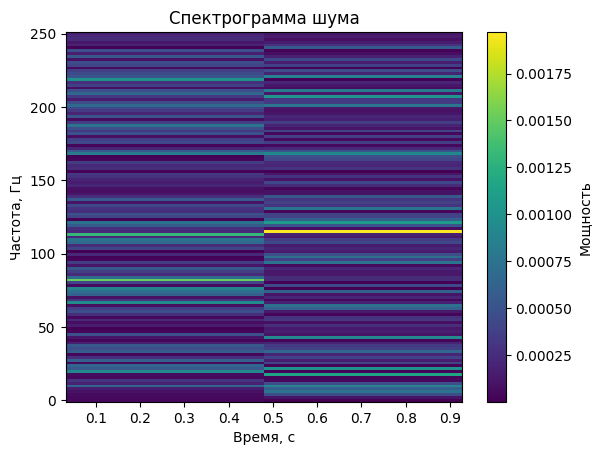

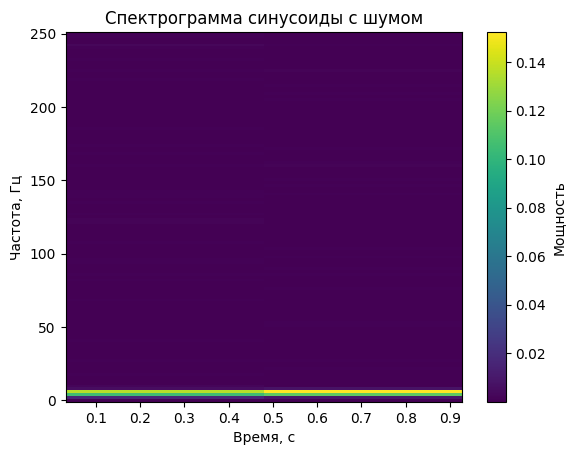

In [24]:
show_spectrogram(sine_values, 500, "Спектрограмма синусоиды")
show_spectrogram(sum_values, 500, "Спектрограмма суммы синусоид")
show_spectrogram(noise_values, 500, "Спектрограмма шума")
show_spectrogram(mixed_values, 500, "Спектрограмма синусоиды с шумом")

In [25]:
# Пример

# Блок №2. Повышенный уровень

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.io import wavfile

## **Задание 1: Чтение и визуализация звукового файла**











В этом задании вам нужно использовать функцию `wavfile.read` из модуля `scipy.io` для чтения звукового файла. Эта функция возвращает частоту дискретизации и данные аудиосигнала. Затем вы должны визуализировать эти данные с помощью `matplotlib.pyplot.plot`. В результате вы получите график амплитуды звукового сигнала во времени.

1. Используйте библиотеку `scipy.io.wavfile` для чтения звукового файла.

In [27]:
sample_rate = 8000
audio_time = np.arange(0, 1, 1 / sample_rate)
sample_audio = 0.6 * np.sin(2 * np.pi * 440 * audio_time)
sample_audio += 0.3 * np.sin(2 * np.pi * 1200 * audio_time)
wavfile.write("sample.wav", sample_rate, (sample_audio * 32767).astype(np.int16))
sample_rate, audio_data = wavfile.read("sample.wav")
print(f"Частота дискретизации: {sample_rate} Гц")

Частота дискретизации: 8000 Гц


2. Визуализируйте временную форму звукового сигнала.

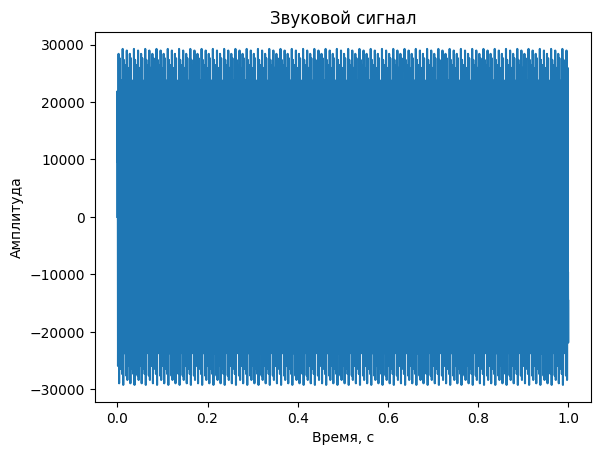

In [28]:
audio_time = np.arange(len(audio_data)) / sample_rate
plt.plot(audio_time, audio_data)
plt.title("Звуковой сигнал")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.show()

In [29]:
# Пример

## **Задание 2: Применение преобразования Фурье**



Преобразование Фурье позволяет перейти от временного представления сигнала к частотному. Для его применения вы можете использовать функцию `fft` из модуля `scipy.fft`. Эта функция возвращает комплексные коэффициенты преобразования Фурье, которые затем можно визуализировать.

1. Примените преобразование Фурье к звуковому сигналу и визуализируйте спектр.

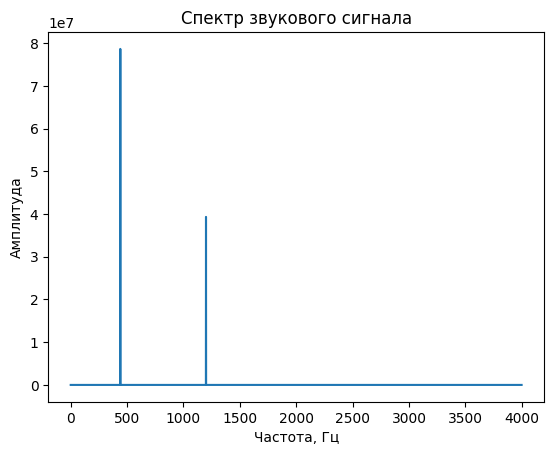

In [30]:
audio_spectrum = fft(audio_data)
audio_frequencies = fftfreq(len(audio_data), 1 / sample_rate)
half = len(audio_data) // 2
plt.plot(audio_frequencies[:half], np.abs(audio_spectrum[:half]))
plt.title("Спектр звукового сигнала")
plt.xlabel("Частота, Гц")
plt.ylabel("Амплитуда")
plt.show()

In [31]:
# Пример

## **Задание 3: Фильтрация сигнала**



Фильтрация сигнала позволяет улучшить качество звука, убрав нежелательные частоты. Для этого вы можете использовать преобразование Фурье, затем обнулить некоторые из его коэффициентов и выполнить обратное преобразование Фурье с помощью функции `ifft` из модуля `scipy.fft`.

1. Создайте функцию для фильтрации сигнала с использованием преобразования Фурье.


In [32]:
def filter_audio(values, sample_rate, cutoff):
    spectrum = fft(values)
    frequencies = fftfreq(len(values), 1 / sample_rate)
    spectrum[np.abs(frequencies) > cutoff] = 0
    return spectrum

In [33]:
filtered_spectrum = filter_audio(audio_data, sample_rate, 700)
print("Сигнал отфильтрован")

Сигнал отфильтрован


2. Примените эту функцию к звуковому сигналу и визуализируйте результаты до и после фильтрации.

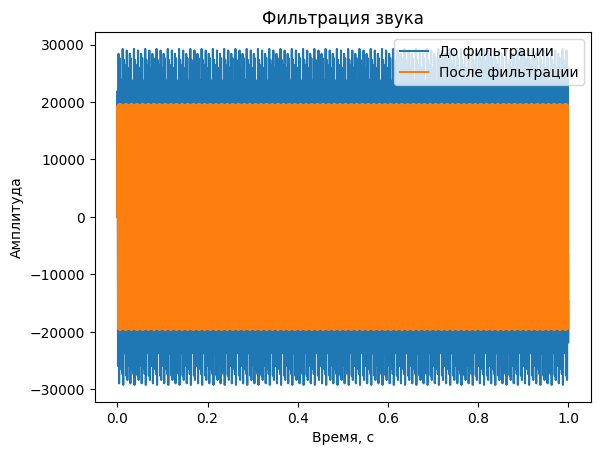

In [34]:
plt.plot(audio_time, audio_data, label="До фильтрации")
plt.plot(audio_time, ifft(filtered_spectrum).real, label="После фильтрации")
plt.title("Фильтрация звука")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.legend()
plt.show()

In [35]:
# Визуализация сигнала до фильтрации

In [36]:
# Визуализация сигнала после фильтрации

## **Задание 4: Обратное преобразование Фурье**



После фильтрации сигнала вы можете применить обратное преобразование Фурье для получения отфильтрованного звукового сигнала во временной области. Затем вы можете сохранить этот сигнал в новый звуковой файл с помощью функции `wavfile.write` из модуля `scipy.io`.

1. Примените обратное преобразование Фурье к отфильтрованному сигналу.


In [37]:
filtered_audio = ifft(filtered_spectrum).real
print(f"Количество отсчётов: {len(filtered_audio)}")

Количество отсчётов: 8000


2. Сохраните полученный сигнал в новый звуковой файл.

In [38]:
wavfile.write("filtered.wav", sample_rate, filtered_audio.astype(np.int16))
print("Файл filtered.wav сохранён")

Файл filtered.wav сохранён
